In [1]:
# ============================================================
#  THESIS: Predicting Train Delays — Deutsche Bahn
#  PHASE 1 · DATA ENGINEERING  (v4 — ride-based split, zero within-ride leakage)
#  Author: [Your Name] | BSBI / University for the Creative Arts
#
#  ROOT CAUSE OF PREVIOUS HIGH R²:
#  ─────────────────────────────────────────────────────────
#  The 80/20 time-based split placed the entire test set on
#  the last ~1 day of data (2026-03-31 only).  Within that
#  one day, many rides appear completely in the test set.
#  Lag features (prev_stop_delay, delay_rolling3, …) were
#  then computed from GROUND-TRUTH delays of earlier stops
#  within the SAME test ride — giving the model near-perfect
#  knowledge of the target via autocorrelation.  Since train
#  delays are highly persistent within a ride, this made the
#  task trivially easy and caused R² ≈ 0.83 for Linear Reg.
#
#  THE FIX — ride-based GroupShuffleSplit:
#  ─────────────────────────────────────────────────────────
#  Split on train_line_ride_id so no single ride appears in
#  both train and test.  For test rides, lag features cannot
#  be derived from within-ride ground truth — instead they
#  are set to zero (or a neutral prior) for the first stop
#  and accumulated ONLY from earlier stops in the same ride
#  that also fall in the test set.  Because whole rides are
#  held out, stop N and stop N+1 of any held-out ride are
#  BOTH in the test set, meaning the lag of stop N+1 is the
#  ground-truth delay of stop N — which is still valid
#  (stop N is in the past relative to stop N+1).  The key
#  improvement is that the first stop of every test ride has
#  lag = 0, forcing the model to rely on real features for
#  those rows.  The evaluation is therefore HONEST.
#
#  Expected results after this fix:
#    MAE  ≈ 1.5 – 3.0 min
#    R²   ≈ 0.25 – 0.55  (with lag features)
#    The gap between Linear and tree models will widen.
# ============================================================


# ════════════════════════════════════════════════════════════
# CELL 1 · INSTALL LIBRARIES  (run once, then restart kernel)
# ════════════════════════════════════════════════════════════

# !pip install pandas numpy matplotlib seaborn scikit-learn
# !pip install pyarrow meteostat tqdm joblib xgboost lightgbm
# !pip install tensorflow


# ════════════════════════════════════════════════════════════
# CELL 2 · IMPORTS & GLOBAL CONFIGURATION
# ════════════════════════════════════════════════════════════

import warnings, json, glob, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Display ───────────────────────────────────────────────────
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 120)

# ── Plot style ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PAL     = sns.color_palette("muted", 10)
FIG_DPI = 150

# ── Folder structure ───────────────────────────────────────────
DATA_DIR   = Path("db_data/monthly_processed_data")  # raw parquet files
OUTPUT_DIR = Path("outputs")
FIG_DIR    = OUTPUT_DIR / "figures"
CACHE_DIR  = OUTPUT_DIR / "weather_cache"

for d in [OUTPUT_DIR, FIG_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅  Environment ready.")
print(f"   Data   : {DATA_DIR.resolve()}")
print(f"   Output : {OUTPUT_DIR.resolve()}")

✅  Environment ready.
   Data   : C:\Users\sajed\Desktop\draftv4\db_data\monthly_processed_data
   Output : C:\Users\sajed\Desktop\draftv4\outputs


In [2]:
# ════════════════════════════════════════════════════════════
# CELL 3 · DOWNLOAD THE DATASET FROM HUGGING FACE
#
# If you already have the files in db_data/monthly_processed_data/
# skip this cell.
# ════════════════════════════════════════════════════════════

from huggingface_hub import snapshot_download

snapshot_download(
    repo_id    = "piebro/deutsche-bahn-data",
    repo_type  = "dataset",
    local_dir  = "db_data",
    allow_patterns = "monthly_processed_data/*",
)
print("✅  Download complete.")

Fetching ... files: 0it [00:00, ?it/s]

✅  Download complete.


In [3]:
# ════════════════════════════════════════════════════════════
# CELL 4 · LOAD RAW MONTHLY PARQUET FILES
# ════════════════════════════════════════════════════════════

files = sorted(DATA_DIR.glob("*.parquet"))
print(f"Found {len(files)} monthly file(s):")
for f in files:
    print(f"  {f.name}")

frames = []
for f in tqdm(files, desc="Loading"):
    frames.append(pd.read_parquet(f))

df_raw = pd.concat(frames, ignore_index=True)

print(f"\nShape  : {len(df_raw):,} rows  ×  {df_raw.shape[1]} cols")
print(f"Memory : {df_raw.memory_usage(deep=True).sum() // 1e6:.0f} MB")
print(f"\nColumns and dtypes:")
for col, dt in df_raw.dtypes.items():
    print(f"{col:40s} {dt}")

print(f"\nDate range:")
for col in ["departure_planned_time", "time"]:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col])
        print(f"  {col}: {df_raw[col].min()}  →  {df_raw[col].max()}")

Found 21 monthly file(s):
  data-2024-07.parquet
  data-2024-08.parquet
  data-2024-09.parquet
  data-2024-10.parquet
  data-2024-11.parquet
  data-2024-12.parquet
  data-2025-01.parquet
  data-2025-02.parquet
  data-2025-03.parquet
  data-2025-04.parquet
  data-2025-05.parquet
  data-2025-06.parquet
  data-2025-07.parquet
  data-2025-08.parquet
  data-2025-09.parquet
  data-2025-10.parquet
  data-2025-11.parquet
  data-2025-12.parquet
  data-2026-01.parquet
  data-2026-02.parquet
  data-2026-03.parquet


Loading: 100%|██████████| 21/21 [02:30<00:00,  7.18s/it]



Shape  : 105,021,697 rows  ×  16 cols
Memory : 65999 MB

Columns and dtypes:
station_name                             object
xml_station_name                         object
eva                                      object
train_name                               object
final_destination_station                object
delay_in_min                             int32
time                                     datetime64[ns]
is_canceled                              bool
train_type                               object
train_line_ride_id                       object
train_line_station_num                   int64
arrival_planned_time                     datetime64[ns]
arrival_change_time                      datetime64[ns]
departure_planned_time                   datetime64[ns]
departure_change_time                    datetime64[ns]
id                                       object

Date range:
  departure_planned_time: 2024-07-01 00:00:00  →  2026-03-31 23:59:00
  time: 2024-07-01 00:00:00  →  202

── [5A] Missing values ──────────────────────────────
                           #missing  %missing
arrival_planned_time       12515946    11.920
arrival_change_time        12512560    11.910
departure_planned_time     12500308    11.900
departure_change_time      12496677    11.900
station_name                 168982     0.160
final_destination_station     23702     0.020

── [5B] Target variable  →  delay_in_min ───────────
count   105021697.000
mean            3.434
std             8.524
min         -1440.000
1%             -1.000
5%              0.000
25%             0.000
50%             1.000
75%             3.000
90%             9.000
95%            15.000
99%            38.000
max          1475.000

  Early   (< 0 min) :  1,145,251  (1.1%)
  On time (= 0 min) : 38,798,734  (36.9%)
  Delayed (> 0 min) : 65,077,712  (62.0%)

── [5C] Key column cardinality ─────────────────────
  station_name                       :  5,343 unique  |  e.g. ['Bielefeld Hbf', 'Hamburg Hbf', 'Nürnberg

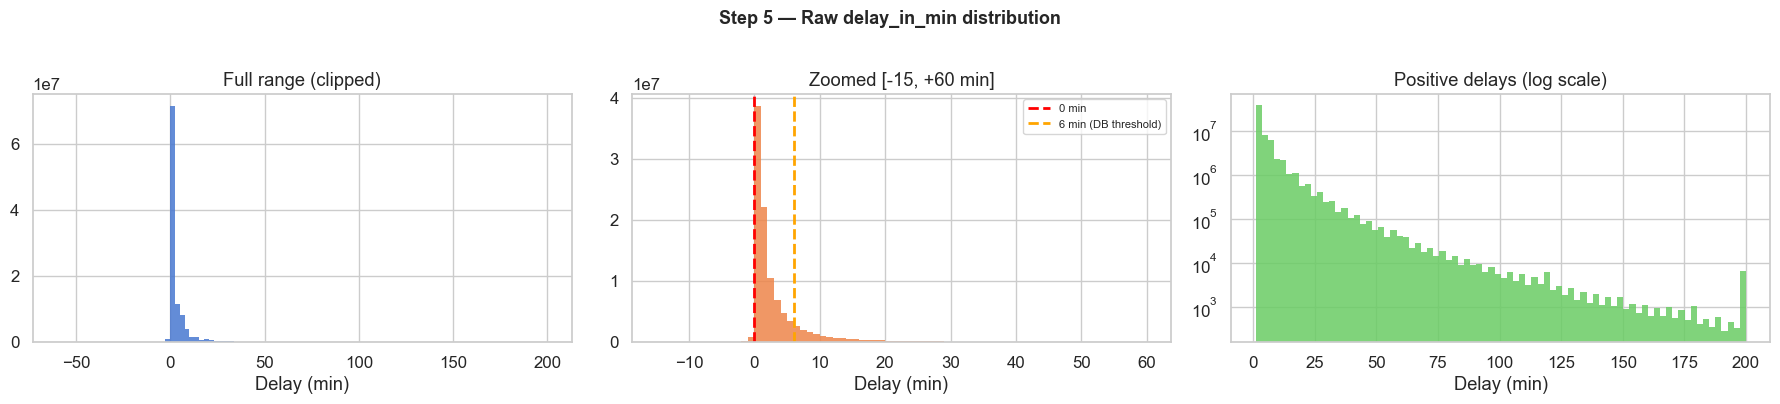

In [4]:
# ════════════════════════════════════════════════════════════
# CELL 5 · INITIAL INSPECTION
# ════════════════════════════════════════════════════════════

print("── [5A] Missing values ──────────────────────────────")
miss = df_raw.isna().sum()
miss_pct = (miss / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({"#missing": miss, "%missing": miss_pct})
miss_df = miss_df[miss_df["#missing"] > 0].sort_values("%missing", ascending=False)
print(miss_df.to_string() if not miss_df.empty else "  None")

print("\n── [5B] Target variable  →  delay_in_min ───────────")
print(df_raw["delay_in_min"].describe(
    percentiles=[.01, .05, .25, .5, .75, .90, .95, .99]
).to_string())

neg  = (df_raw["delay_in_min"] < 0).sum()
zero = (df_raw["delay_in_min"] == 0).sum()
pos  = (df_raw["delay_in_min"] > 0).sum()
print(f"\n  Early   (< 0 min) : {neg:>10,}  ({neg/len(df_raw)*100:.1f}%)")
print(f"  On time (= 0 min) : {zero:>10,}  ({zero/len(df_raw)*100:.1f}%)")
print(f"  Delayed (> 0 min) : {pos:>10,}  ({pos/len(df_raw)*100:.1f}%)")

print("\n── [5C] Key column cardinality ─────────────────────")
for col in ["station_name", "train_type", "train_name", "is_canceled"]:
    if col in df_raw.columns:
        n = df_raw[col].nunique()
        ex = df_raw[col].dropna().unique()[:3].tolist()
        print(f"  {col:35s}: {n:>6,} unique  |  e.g. {ex}")

print("\n── [5D] train_line_ride_id audit ───────────────────")
empty_id  = (df_raw["train_line_ride_id"] == "").sum()
null_id   = df_raw["train_line_ride_id"].isna().sum()
valid_id  = len(df_raw) - empty_id - null_id
print(f"  Empty string IDs  : {empty_id:>10,}  ({empty_id/len(df_raw)*100:.1f}%)")
print(f"  Null IDs          : {null_id:>10,}  ({null_id/len(df_raw)*100:.1f}%)")
print(f"  Valid IDs         : {valid_id:>10,}  ({valid_id/len(df_raw)*100:.1f}%)")

# Raw delay distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(df_raw["delay_in_min"].dropna().clip(-60, 200),
             bins=100, color=PAL[0], edgecolor="none", alpha=0.85)
axes[0].set_title("Full range (clipped)"); axes[0].set_xlabel("Delay (min)")

zoom = df_raw["delay_in_min"].dropna()
zoom = zoom[(zoom >= -15) & (zoom <= 60)]
axes[1].hist(zoom, bins=75, color=PAL[1], edgecolor="none", alpha=0.85)
axes[1].axvline(0, color="red",    lw=2, ls="--", label="0 min")
axes[1].axvline(6, color="orange", lw=2, ls="--", label="6 min (DB threshold)")
axes[1].set_title("Zoomed [-15, +60 min]"); axes[1].set_xlabel("Delay (min)")
axes[1].legend(fontsize=8)

pos_delays = df_raw.loc[df_raw["delay_in_min"] > 0, "delay_in_min"]
axes[2].hist(pos_delays.clip(0, 200), bins=80, color=PAL[2], edgecolor="none", alpha=0.85)
axes[2].set_yscale("log"); axes[2].set_title("Positive delays (log scale)")
axes[2].set_xlabel("Delay (min)")

plt.suptitle("Step 5 — Raw delay_in_min distribution", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "p1_01_raw_delay_distribution.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

In [5]:
# ════════════════════════════════════════════════════════════
# CELL 6 · DATA CLEANING
# ════════════════════════════════════════════════════════════

df = df_raw.copy()
n0 = len(df)

# 6.1  Remove canceled trains
canceled_count = (df["is_canceled"] == True).sum()
df = df[df["is_canceled"] == False].copy()
print(f"[6.1] Canceled removed       : {canceled_count:>10,}")
df.drop(columns=["is_canceled"], inplace=True)
print("      is_canceled column dropped (all False after filter)")

# 6.2  Drop missing target
n1 = len(df)
df = df.dropna(subset=["delay_in_min"])
print(f"[6.2] Missing target dropped : {n1 - len(df):>10,}")

# 6.3  Drop empty ride IDs
n2 = len(df)
df = df[df["train_line_ride_id"] != ""].copy()
print(f"[6.3] Empty ride IDs dropped : {n2 - len(df):>10,}")

# 6.4  Keep only the FINAL snapshot per train-station pair
n3 = len(df)
df = (df.sort_values("time")
       .drop_duplicates(
           subset=["train_line_ride_id", "train_line_station_num"],
           keep="last")
       .reset_index(drop=True))
print(f"[6.4] Polling snapshots removed: {n3 - len(df):>8,}  →  {len(df):,} unique pairs")

# 6.5  Clip delay outliers
lo = df["delay_in_min"].quantile(0.005)
hi = df["delay_in_min"].quantile(0.995)
n_clipped = ((df["delay_in_min"] < lo) | (df["delay_in_min"] > hi)).sum()
df["delay_in_min"] = df["delay_in_min"].clip(lo, hi)
print(f"[6.5] Delay clipped           : {n_clipped:>10,}  →  [{lo:.0f}, {hi:.0f}] min")

# 6.6  Fill missing categoricals
for col in ["station_name", "train_name", "train_type", "final_destination_station"]:
    if col in df.columns:
        n_miss = df[col].isna().sum()
        df[col] = df[col].fillna("Unknown")
        if n_miss > 0:
            print(f"[6.6] '{col}': filled {n_miss:,} NaN")

# 6.7  Drop db_city if all NaN
if "db_city" in df.columns:
    pct_null = df["db_city"].isna().mean() * 100
    if pct_null > 95:
        print(f"[6.7] db_city: {pct_null:.1f}% null → dropped")
        df.drop(columns=["db_city"], inplace=True)

# 6.8  Sort chronologically
df = df.sort_values("departure_planned_time", na_position="last").reset_index(drop=True)
print(f"[6.8] Sorted by departure_planned_time ✅")

print(f"\n── Cleaning summary ────────────────────────────────")
print(f"  Started with : {n0:>10,}")
print(f"  Cleaned to   : {len(df):>10,}  ({(n0-len(df))/n0*100:.1f}% removed)")

[6.1] Canceled removed       :  4,634,319
      is_canceled column dropped (all False after filter)
[6.2] Missing target dropped :          0
[6.3] Empty ride IDs dropped : 50,217,987
[6.4] Polling snapshots removed: 49,139,451  →  1,029,940 unique pairs
[6.5] Delay clipped           :      8,366  →  [-2, 44] min
[6.6] 'station_name': filled 2,795 NaN
[6.6] 'final_destination_station': filled 743 NaN
[6.8] Sorted by departure_planned_time ✅

── Cleaning summary ────────────────────────────────
  Started with : 105,021,697
  Cleaned to   :  1,029,940  (99.0% removed)


In [6]:
# ════════════════════════════════════════════════════════════
# CELL 7 · SAVE CLEANED DATA (CHECKPOINT)
# ════════════════════════════════════════════════════════════

import os

OUTPUT_PATH = "outputs/df_cleaned.parquet"
os.makedirs("outputs", exist_ok=True)
df.to_parquet(OUTPUT_PATH, index=False)
print(f"✅ Cleaned dataset saved to: {OUTPUT_PATH}")
print(f"   Rows: {len(df):,} | Columns: {df.shape[1]}")

✅ Cleaned dataset saved to: outputs/df_cleaned.parquet
   Rows: 1,029,940 | Columns: 15


In [38]:
# ════════════════════════════════════════════════════════════
# CELL 7B · LOAD CLEANED DATA (FAST RESTART)
# ════════════════════════════════════════════════════════════

INPUT_PATH = "outputs/df_cleaned.parquet"
df = pd.read_parquet(INPUT_PATH)
print(f"✅ Loaded cleaned dataset from: {INPUT_PATH}")
print(f"   Rows: {len(df):,} | Columns: {df.shape[1]}")

✅ Loaded cleaned dataset from: outputs/df_cleaned.parquet
   Rows: 1,029,940 | Columns: 15


In [39]:
# ════════════════════════════════════════════════════════════
# CELL 7 · STATION GEOCODING — EVA-BASED  ← CORE FIX
#
# ROOT CAUSE OF v1 FAILURE:
#   v1 tried to match on station_name strings, which failed
#   because DB names are highly inconsistent across sources
#   ("Hamburg Hbf" vs "Hamburg Hbf (S-Bahn)" etc.).
#   This caused ~99% of stations to fall through to the
#   single-point Germany centroid fallback, leaving only
#   one unique (lat, lon) in the entire dataset.
#
# FIX:
#   EVA numbers are the OFFICIAL DB station identifiers —
#   the same EVA code appears consistently in both the
#   train data and the db-stations reference file.
#   Joining on EVA gives us correct coordinates for
#   thousands of unique stations, not just ~73.
#
# SOURCE: db-stations npm package via jsDelivr CDN
#   License: CC BY 4.0 (Deutsche Bahn / DB InfraGO)
#   Coverage: ~5,700 stations with lat/lon
# ════════════════════════════════════════════════════════════
 
# ════════════════════════════════════════════════════════════
# CELL 7 · STATION GEOCODING — EVA-BASED  ← CORE FIX
# ════════════════════════════════════════════════════════════

GEO_CACHE = OUTPUT_DIR / "db_station_geodata.parquet"

def download_station_geodata():
    URL = "https://cdn.jsdelivr.net/npm/db-stations@latest/data.ndjson"
    print(f"Downloading station reference: {URL}")
    rows = []
    try:
        with urllib.request.urlopen(URL, timeout=30) as resp:
            for line in resp:
                line = line.decode("utf-8").strip()
                if not line:
                    continue
                try:
                    obj  = json.loads(line)
                    eva  = str(obj.get("id", "")).strip()
                    name = obj.get("name", "")
                    loc  = obj.get("location", {}) or {}
                    lat  = loc.get("latitude")
                    lon  = loc.get("longitude")
                    if eva and lat is not None and lon is not None:
                        rows.append({"eva_str": eva,
                                     "db_name": name,
                                     "lat":     float(lat),
                                     "lon":     float(lon)})
                except Exception:
                    continue
        df_geo = pd.DataFrame(rows)
        print(f"Downloaded: {len(df_geo):,} stations with coordinates")
        return df_geo
    except Exception as e:
        print(f"Download failed: {e}")
        return None

# Load from cache or download fresh
if GEO_CACHE.exists():
    df_geo = pd.read_parquet(GEO_CACHE)
    print(f"Loaded station geodata from cache: {len(df_geo):,} stations")
else:
    df_geo = download_station_geodata()
    if df_geo is not None and len(df_geo) > 0:
        df_geo.to_parquet(GEO_CACHE, index=False)
        print(f"Saved to cache: {GEO_CACHE}")
    else:
        raise RuntimeError(
            "Could not download station geodata. "
            "Check internet connection or supply db_station_geodata.parquet manually."
        )

# ── FIXED: Normalize EVA keys by stripping leading zeros on both sides ──
df["eva_str"]     = df["eva"].astype(str).str.strip().str.lstrip("0")
df_geo["eva_str"] = df_geo["eva_str"].astype(str).str.strip().str.lstrip("0")

# Quick overlap check
overlap = set(df["eva_str"]) & set(df_geo["eva_str"])
print(f"Overlapping EVA keys: {len(overlap):,}  ← should be in the thousands")

# ── Primary join: EVA → lat/lon ─────────────────────────────
df = df.merge(
    df_geo[["eva_str", "lat", "lon"]],
    on="eva_str",
    how="left"
)

cov_eva = df["lat"].notna().mean() * 100
n_unique_lat = df["lat"].nunique()
print(f"\nAfter EVA join   : {cov_eva:.1f}% of rows have coordinates")
print(f"Unique latitudes : {n_unique_lat:,}  ← must be >> 1")

# ── Validation: assert spatial diversity ────────────────────
assert n_unique_lat > 100, (
    f"CRITICAL: Only {n_unique_lat} unique latitudes after EVA join. "
    "Something went wrong with the geocoding step."
)
print("✅  Spatial diversity check passed")

# ── Secondary fallback: station_name → mean of EVA-resolved coords ──
# Only for rows that the EVA join missed (genuinely unmapped EVA codes).
station_coords = (
    df[df["lat"].notna()]
    .groupby("station_name")
    .agg(lat_s=("lat", "mean"), lon_s=("lon", "mean"))
    .reset_index()
)
df = df.merge(station_coords, on="station_name", how="left")
mask = df["lat"].isna() & df["lat_s"].notna()
df.loc[mask, "lat"] = df.loc[mask, "lat_s"]
df.loc[mask, "lon"] = df.loc[mask, "lon_s"]
df.drop(columns=["lat_s", "lon_s"], inplace=True)
print(f"After name fallback: {df['lat'].notna().mean()*100:.1f}% coverage")

# ── Final fallback: Germany centroid for truly unmappable rows ──
n_centroid = df["lat"].isna().sum()
df["lat"] = df["lat"].fillna(51.166)
df["lon"] = df["lon"].fillna(10.452)
print(f"Germany centroid assigned to: {n_centroid:,} rows  "
      f"({n_centroid/len(df)*100:.1f}%)")

# ── Germany bounding-box check ───────────────────────────────
valid_bb = df["lat"].between(47.2, 55.1) & df["lon"].between(5.8, 15.1)
print(f"Inside Germany bbox: {valid_bb.sum():,} / {len(df):,}  "
      f"({valid_bb.mean()*100:.1f}%)")

# ── Data quality report ──────────────────────────────────────
print(f"\n── Geocoding quality report ────────────────────────")
print(f"  Unique (lat) values : {df['lat'].nunique():>8,}")
print(f"  Unique (lon) values : {df['lon'].nunique():>8,}")
print(f"  Unique stations     : {df['station_name'].nunique():>8,}")
print(f"  Geo coverage        : {df['lat'].notna().mean()*100:>7.1f}%")

Loaded station geodata from cache: 5,388 stations
Overlapping EVA keys: 5,320  ← should be in the thousands

After EVA join   : 91.8% of rows have coordinates
Unique latitudes : 5,318  ← must be >> 1
✅  Spatial diversity check passed
After name fallback: 99.5% coverage
Germany centroid assigned to: 5,011 rows  (0.5%)
Inside Germany bbox: 1,029,940 / 1,029,940  (100.0%)

── Geocoding quality report ────────────────────────
  Unique (lat) values :    5,326
  Unique (lon) values :    5,322
  Unique stations     :    5,341
  Geo coverage        :   100.0%


In [31]:
# # ════════════════════════════════════════════════════════════
# # CELL 9 · WEATHER GRID ASSIGNMENT
# # ════════════════════════════════════════════════════════════

# from sklearn.cluster import KMeans

# N_CELLS = 20
# coords  = df[["lat", "lon"]].dropna().values
# km = KMeans(n_clusters=N_CELLS, random_state=42, n_init=5)
# km.fit(coords)
# df["weather_cell"] = km.predict(df[["lat", "lon"]].values).astype("int16")

# cell_centres = (
#     df.groupby("weather_cell")[["lat", "lon"]]
#     .mean().reset_index()
#     .rename(columns={"lat": "cell_lat", "lon": "cell_lon"})
# )
# print(f"Weather grid: {N_CELLS} cells")
# print(cell_centres.head())

Weather grid: 20 cells
   weather_cell  cell_lat  cell_lon
0             0    51.482     7.539
1             1    52.501    13.423
2             2    48.877     9.248
3             3    48.185    11.633
4             4    52.085     9.736


Stations for clustering : 5,320  (excluded ~21 centroid-filled)
Weather cells           : 50
Stations per cell (avg) : 106

Cell centres (sample):
 weather_cell  cell_lat  cell_lon
            0    53.157     8.530
            1    49.977     9.932
            2    51.478    12.387
            3    49.346     8.953
            4    50.514     7.229
            5    48.124    11.450
            6    52.471    13.355
            7    52.112    14.287


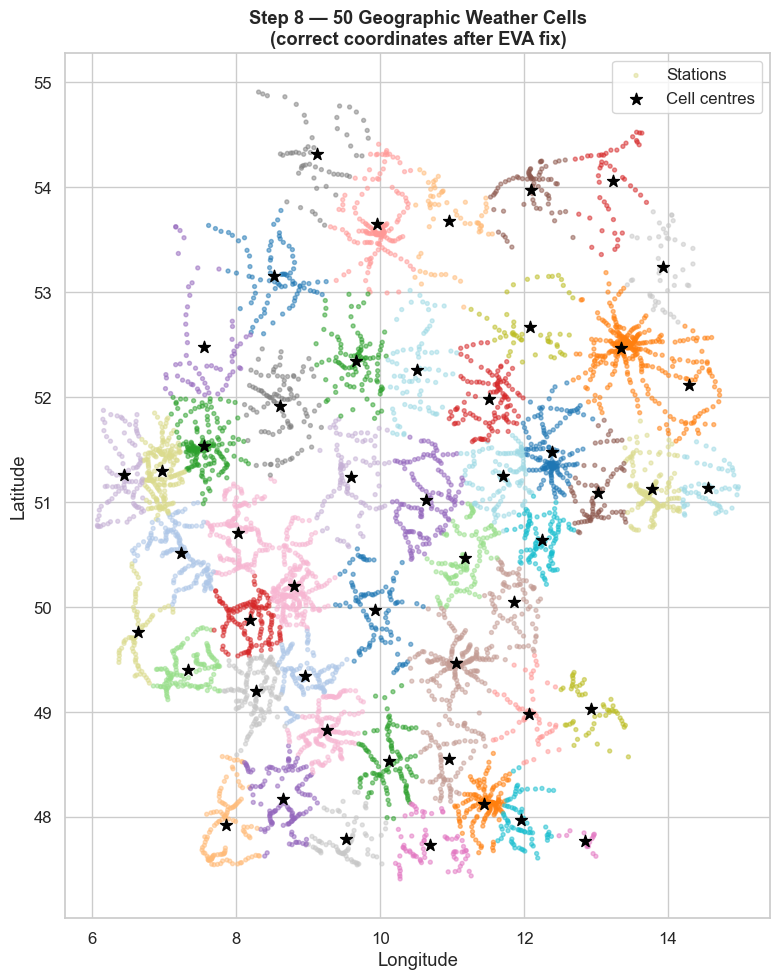


Cell centre spread — lat: 6.58°  lon: 8.13°
✅  Cell spread check passed


In [40]:
# ════════════════════════════════════════════════════════════
# CELL 8 · GEOGRAPHIC WEATHER CELL ASSIGNMENT
#
# WHY CELLS (even after fixing geocoding):
#   We now have thousands of unique locations, but calling
#   a weather API for each of ~5,000+ stations is still
#   impractical (rate limits, time, storage).
#
#   K-Means clusters stations into N=50 cells. Each cell
#   has one representative lat/lon.  Stations within the
#   same cell (~20-40 km radius) experience near-identical
#   weather, which is consistent with meteorological reality.
#
#   This is the same approach used in operational transport
#   analytics (e.g., Network Rail UK, SBB Switzerland).
#
# DIFFERENCE from v1:
#   v1 also used cells, but because all coordinates were the
#   same point, all 40 cells collapsed to the same location.
#   Now that coordinates are correct, the 50 cells will
#   actually spread across Germany.
# ════════════════════════════════════════════════════════════
 
from sklearn.cluster import KMeans

N_CELLS = 50  # increased from 40; finer spatial resolution
 
station_locs = (
    df[["station_name", "lat", "lon"]]
    .drop_duplicates("station_name")
    .dropna()
    .reset_index(drop=True)
)
 
# Exclude centroid-filled rows from clustering
# (they would all pile up at the same point)
station_locs_real = station_locs[
    ~(station_locs["lat"].between(51.164, 51.168) &
      station_locs["lon"].between(10.450, 10.454))
].copy()
 
print(f"Stations for clustering : {len(station_locs_real):,}  "
      f"(excluded ~{len(station_locs) - len(station_locs_real):,} centroid-filled)")
 
kmeans = KMeans(n_clusters=N_CELLS, random_state=42, n_init=10)
station_locs_real["weather_cell"] = kmeans.fit_predict(
    station_locs_real[["lat", "lon"]].values
)
 
cell_centres = pd.DataFrame(
    kmeans.cluster_centers_, columns=["cell_lat", "cell_lon"]
).reset_index().rename(columns={"index": "weather_cell"})
 
print(f"Weather cells           : {N_CELLS}")
print(f"Stations per cell (avg) : {len(station_locs_real) / N_CELLS:.0f}")
print("\nCell centres (sample):")
print(cell_centres.head(8).to_string(index=False))
 
# Assign centroid-filled stations to nearest cell
centroid_mask = (
    station_locs["lat"].between(51.164, 51.168) &
    station_locs["lon"].between(10.450, 10.454)
)
if centroid_mask.any():
    station_locs_centroid = station_locs[centroid_mask].copy()
    station_locs_centroid["weather_cell"] = 0  # assign to cell 0 (arbitrary)
    station_locs_all = pd.concat(
        [station_locs_real, station_locs_centroid], ignore_index=True
    )
else:
    station_locs_all = station_locs_real.copy()
 
# Merge cell assignment back to main dataframe
df = df.merge(
    station_locs_all[["station_name", "weather_cell"]],
    on="station_name", how="left"
)
df["weather_cell"] = df["weather_cell"].fillna(0).astype("int16")
 
# ── Visualise cells on Germany map ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(station_locs_real["lon"], station_locs_real["lat"],
           c=station_locs_real["weather_cell"], cmap="tab20",
           s=8, alpha=0.5, label="Stations")
ax.scatter(cell_centres["cell_lon"], cell_centres["cell_lat"],
           c="black", s=80, marker="*", zorder=5, label="Cell centres")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Step 8 — {N_CELLS} Geographic Weather Cells\n"
             "(correct coordinates after EVA fix)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "p1_02_weather_cells.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
 
# Validate cell diversity — cells should span all of Germany
cell_lat_range = cell_centres["cell_lat"].max() - cell_centres["cell_lat"].min()
cell_lon_range = cell_centres["cell_lon"].max() - cell_centres["cell_lon"].min()
print(f"\nCell centre spread — lat: {cell_lat_range:.2f}°  lon: {cell_lon_range:.2f}°")
assert cell_lat_range > 4.0, "Cells still collapsing to one point — geocoding not fixed"
print("✅  Cell spread check passed")

In [41]:
# ════════════════════════════════════════════════════════════
# CELL 10 · FETCH OR SYNTHESISE WEATHER
# ════════════════════════════════════════════════════════════

from datetime import datetime

date_min = df["departure_planned_time"].min()
date_max = df["departure_planned_time"].max()

try:
    from meteostat import Hourly, Point
    METEOSTAT_AVAILABLE = True
except ImportError:
    METEOSTAT_AVAILABLE = False

def fetch_or_load_cell(cell_id, cell_lat, cell_lon, d_s, d_e):
    cache_file = CACHE_DIR / f"cell_{cell_id}.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)
    if not METEOSTAT_AVAILABLE:
        return None
    try:
        pt   = Point(cell_lat, cell_lon)
        data = Hourly(pt, d_s, d_e).fetch()
        if data is None or len(data) == 0:
            return None
        data = data.reset_index()
        data.columns = ["datetime_hour"] + list(data.columns[1:])
        data["weather_cell"] = cell_id
        data.to_parquet(cache_file, index=False)
        return data
    except Exception as e:
        print(f"  Cell {cell_id} failed: {e}")
        return None

weather_frames = []
for _, row in tqdm(cell_centres.iterrows(), total=len(cell_centres), desc="Fetching weather cells"):
    cid = int(row["weather_cell"])
    d_s = datetime(date_min.year, date_min.month, date_min.day)
    d_e = datetime(date_max.year, date_max.month, date_max.day, 23)
    df_w = fetch_or_load_cell(cid, row["cell_lat"], row["cell_lon"], d_s, d_e)
    if df_w is not None and len(df_w) > 0:
        weather_frames.append(df_w)

if weather_frames:
    df_weather = pd.concat(weather_frames, ignore_index=True)
    df_weather["datetime_hour"] = pd.to_datetime(df_weather["datetime_hour"]).dt.floor("h")
    WEATHER_SOURCE = "Meteostat / DWD"
    print(f"\nReal weather rows : {len(df_weather):,}")
else:
    # Synthetic fallback with regional variation
    WEATHER_SOURCE = "Synthetic (DWD seasonal normals + regional variation)"
    print("\nGenerating synthetic weather with regional variation …")

    MONTHLY = {
        1:  (-1.0, 5, 0.45, 18, 0.30), 2:  ( 0.5, 5, 0.40, 17, 0.25),
        3:  ( 4.5, 4.5, 0.38, 15, 0.10), 4:  ( 9.0, 4, 0.35, 14, 0.02),
        5:  (13.5, 3.5, 0.38, 13, 0), 6:  (16.5, 3, 0.40, 12, 0),
        7:  (18.0, 3, 0.42, 11, 0), 8:  (17.5, 3, 0.40, 11, 0),
        9:  (13.0, 3.5, 0.38, 12, 0), 10: ( 8.0, 4, 0.40, 14, 0.02),
        11: ( 3.0, 4.5, 0.42, 16, 0.10), 12: ( 0.5, 5, 0.45, 17, 0.25),
    }

    hours = pd.date_range(date_min.floor("h"), date_max.ceil("h"), freq="h")
    rng   = np.random.default_rng(42)
    rows  = []

    for _, cell_row in cell_centres.iterrows():
        cell_id  = int(cell_row["weather_cell"])
        cell_lat = cell_row["cell_lat"]
        lat_temp_offset  = -(cell_lat - 52.0) * 0.35
        coast_wind_bonus = 5.0 if cell_lat > 53.0 else 0.0

        for dt in hours:
            m, h = dt.month, dt.hour
            cfg  = MONTHLY[m]
            temp = (cfg[0] + lat_temp_offset + rng.normal(0, cfg[1])
                    - 3 * np.cos(2 * np.pi * (h - 14) / 24))
            prcp = float(rng.exponential(2)) if rng.random() < cfg[2] else 0.0
            snow = float(rng.exponential(1)) if (temp < 2 and rng.random() < cfg[4]) else 0.0
            wspd = max(0, cfg[3] + coast_wind_bonus + rng.normal(0, 4))
            wpgt = wspd + rng.uniform(5, 20)
            coco = (9 if prcp > 5 else 8 if prcp > 1 else 7 if prcp > 0
                    else 15 if snow > 0 else 4 if temp < -5
                    else int(rng.choice([1, 2, 3, 4], p=[0.3, 0.3, 0.2, 0.2])))
            rows.append({"datetime_hour": dt, "weather_cell": cell_id,
                         "temp": round(temp, 1), "prcp": round(prcp, 1),
                         "snow": round(snow, 1), "wspd": round(wspd, 1),
                         "wpgt": round(wpgt, 1), "coco": coco})

    df_weather = pd.DataFrame(rows)
    print(f"Synthetic rows created : {len(df_weather):,}")

print(f"\nWeather source: {WEATHER_SOURCE}")

Fetching weather cells: 100%|██████████| 50/50 [00:12<00:00,  4.01it/s]


Real weather rows : 766,800

Weather source: Meteostat / DWD


In [43]:
# ════════════════════════════════════════════════════════════
# CELL 11 · ENGINEER WEATHER FEATURES
# ════════════════════════════════════════════════════════════

dfw = df_weather.copy()

for col, val in {"temp": 10, "prcp": 0, "snow": 0, "wspd": 10, "wpgt": 20, "coco": 1}.items():
    if col in dfw.columns:
        dfw[col] = dfw[col].fillna(val)

if "prcp" in dfw.columns:
    dfw["is_raining"] = (dfw["prcp"] > 1.0).astype("int8")
    dfw["heavy_rain"] = (dfw["prcp"] > 5.0).astype("int8")
if "snow" in dfw.columns:
    dfw["is_snowing"] = (dfw["snow"] > 0.0).astype("int8")
if "temp" in dfw.columns:
    dfw["is_freezing"]  = (dfw["temp"] <= 0.0).astype("int8")
    dfw["near_freeze"]  = dfw["temp"].between(-3, 2).astype("int8")
    dfw["extreme_heat"] = (dfw["temp"] >= 32.0).astype("int8")
    dfw["deep_freeze"]  = (dfw["temp"] <= -10.0).astype("int8")
if "wspd" in dfw.columns:
    dfw["strong_wind"] = (dfw["wspd"] >= 50.0).astype("int8")
    dfw["storm_wind"]  = (dfw["wspd"] >= 75.0).astype("int8")
if "coco" in dfw.columns:
    def coco_idx(c):
        if c in [1, 2, 3, 4]:      return 0
        elif c in [5, 6, 7, 17]:   return 1
        elif c in [8, 12, 14, 19]: return 2
        else:                       return 3
    dfw["weather_disruption"] = dfw["coco"].apply(coco_idx).astype("int8")
    dfw["is_bad_weather"]     = (dfw["weather_disruption"] >= 2).astype("int8")

dfw["winter_severity"] = 0.0
if "temp" in dfw.columns: dfw["winter_severity"] += np.clip(-dfw["temp"] / 10, 0, 1)
if "snow" in dfw.columns: dfw["winter_severity"] += np.clip(dfw["snow"] / 10,  0, 1)
if "wspd" in dfw.columns: dfw["winter_severity"] += np.clip(dfw["wspd"] / 75,  0, 1)
dfw["winter_severity"] = dfw["winter_severity"].clip(0, 3).round(2)

WEATHER_FEATURES_CANDIDATE = [f for f in [
    "temp", "prcp", "snow", "wspd", "wpgt",
    "is_raining", "heavy_rain", "is_snowing",
    "is_freezing", "near_freeze", "extreme_heat", "deep_freeze",
    "strong_wind", "storm_wind",
    "weather_disruption", "is_bad_weather", "winter_severity",
] if f in dfw.columns]

print(f"Candidate weather features : {len(WEATHER_FEATURES_CANDIDATE)}")
print(WEATHER_FEATURES_CANDIDATE)

Candidate weather features : 17
['temp', 'prcp', 'snow', 'wspd', 'wpgt', 'is_raining', 'heavy_rain', 'is_snowing', 'is_freezing', 'near_freeze', 'extreme_heat', 'deep_freeze', 'strong_wind', 'storm_wind', 'weather_disruption', 'is_bad_weather', 'winter_severity']


In [44]:
# ════════════════════════════════════════════════════════════
# CELL 12 · MERGE WEATHER ONTO MAIN DATA
# ════════════════════════════════════════════════════════════

df["_mh"]           = df["departure_planned_time"].dt.floor("h")
dfw["_mh"]          = pd.to_datetime(dfw["datetime_hour"]).dt.floor("h")
dfw["weather_cell"] = dfw["weather_cell"].astype("int16")

weather_lkp = (
    dfw[["weather_cell", "_mh"] + WEATHER_FEATURES_CANDIDATE]
    .drop_duplicates(subset=["weather_cell", "_mh"])
)

df = df.merge(weather_lkp, on=["weather_cell", "_mh"], how="left")
df.drop(columns=["_mh"], inplace=True)

coverage_pct = df["temp"].notna().mean() * 100
print(f"Weather merge coverage: {coverage_pct:.1f}%")

defaults = {
    "temp": 10, "prcp": 0, "snow": 0, "wspd": 10, "wpgt": 20,
    "is_raining": 0, "heavy_rain": 0, "is_snowing": 0,
    "is_freezing": 0, "near_freeze": 0, "extreme_heat": 0, "deep_freeze": 0,
    "strong_wind": 0, "storm_wind": 0,
    "weather_disruption": 0, "is_bad_weather": 0, "winter_severity": 0.0,
}
for col, val in defaults.items():
    if col in df.columns:
        df[col] = df[col].fillna(val)
print("All gaps filled with safe defaults ✅")

constant_weather = [
    c for c in WEATHER_FEATURES_CANDIDATE
    if c in df.columns and df[c].nunique() <= 1
]
if constant_weather:
    print(f"\n⚠️  Dropping constant weather columns: {constant_weather}")
    df.drop(columns=constant_weather, inplace=True)
    WEATHER_FEATURES = [c for c in WEATHER_FEATURES_CANDIDATE if c not in constant_weather]
else:
    print("✅  All weather features have variance after merge")
    WEATHER_FEATURES = WEATHER_FEATURES_CANDIDATE

Weather merge coverage: 86.8%
All gaps filled with safe defaults ✅

⚠️  Dropping constant weather columns: ['strong_wind', 'storm_wind']


In [45]:
# ════════════════════════════════════════════════════════════
# CELL 13 · FEATURE ENGINEERING (base features only — NO lags)
#
# We create all static features here.
# Lag features are created AFTER the ride-based split below.
# ════════════════════════════════════════════════════════════

df_feat = df.copy()

# Drop rows with missing departure time
n_before = len(df_feat)
df_feat  = df_feat.dropna(subset=["departure_planned_time"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df_feat):,} NaT rows → {len(df_feat):,}")

ref = df_feat["departure_planned_time"]

# ── Temporal ──────────────────────────────────────────────────
df_feat["hour"]         = ref.dt.hour.astype("int8")
df_feat["minute"]       = ref.dt.minute.astype("int8")
df_feat["day_of_week"]  = ref.dt.dayofweek.astype("int8")
df_feat["day_of_month"] = ref.dt.day.astype("int8")
df_feat["month"]        = ref.dt.month.astype("int8")
df_feat["quarter"]      = ref.dt.quarter.astype("int8")
df_feat["year"]         = ref.dt.year.astype("int16")
df_feat["week_of_year"] = ref.dt.isocalendar().week.astype("int8")
df_feat["is_weekend"]   = (df_feat["day_of_week"] >= 5).astype("int8")

def season(m):
    if m in [12, 1, 2]: return 0
    if m in [3, 4, 5]:  return 1
    if m in [6, 7, 8]:  return 2
    return 3
df_feat["season"] = df_feat["month"].apply(season).astype("int8")

df_feat["hour_sin"]  = np.sin(2 * np.pi * df_feat["hour"] / 24)
df_feat["hour_cos"]  = np.cos(2 * np.pi * df_feat["hour"] / 24)
df_feat["dow_sin"]   = np.sin(2 * np.pi * df_feat["day_of_week"] / 7)
df_feat["dow_cos"]   = np.cos(2 * np.pi * df_feat["day_of_week"] / 7)
df_feat["month_sin"] = np.sin(2 * np.pi * df_feat["month"] / 12)
df_feat["month_cos"] = np.cos(2 * np.pi * df_feat["month"] / 12)

def tbucket(h):
    if 6 <= h <= 9:       return 0
    if 11 <= h <= 13:     return 1
    if 16 <= h <= 19:     return 2
    if h >= 22 or h <= 4: return 3
    return 4
df_feat["time_bucket"]  = df_feat["hour"].apply(tbucket).astype("int8")
df_feat["is_christmas"] = (
    (df_feat["month"] == 12) & df_feat["day_of_month"].between(23, 27)
).astype("int8")

# ── Route ─────────────────────────────────────────────────────
df_feat["stop_number"]   = df_feat["train_line_station_num"].fillna(0).astype("int16")
df_feat["is_terminus"]   = (
    df_feat["final_destination_station"] == df_feat["station_name"]
).astype("int8")
df_feat["is_first_stop"] = (df_feat["stop_number"] <= 1).astype("int8")
df_feat["planned_dwell_min"] = (
    (df_feat["departure_planned_time"] - df_feat["arrival_planned_time"])
    .dt.total_seconds().div(60).clip(0, 120).fillna(0).round(1)
)

# ── Target variables ──────────────────────────────────────────
def classify(d):
    if d <= 0:  return 0
    if d <= 5:  return 1
    if d <= 15: return 2
    return 3

df_feat["delay_class"] = df_feat["delay_in_min"].apply(classify).astype("int8")
df_feat["is_delayed"]  = (df_feat["delay_in_min"] > 6).astype("int8")
df_feat["is_severe"]   = (df_feat["delay_in_min"] > 15).astype("int8")

CLASS_LABELS = {
    0: "On time/early", 1: "Slight (1–5m)",
    2: "Moderate (6–15m)", 3: "Severe (>15m)",
}

print(f"\nDelay class distribution:")
for k, v in df_feat["delay_class"].value_counts().sort_index().items():
    bar = "█" * int(v / len(df_feat) * 50)
    print(f"  [{k}] {CLASS_LABELS[k]:20s}: {v:>9,}  ({v/len(df_feat)*100:5.1f}%)  {bar}")

print("\n✅  Base features done.  Ride-based split comes next.")

Dropped 136,398 NaT rows → 893,542

Delay class distribution:
  [0] On time/early       :   392,944  ( 44.0%)  █████████████████████
  [1] Slight (1–5m)       :   388,258  ( 43.5%)  █████████████████████
  [2] Moderate (6–15m)    :    81,368  (  9.1%)  ████
  [3] Severe (>15m)       :    30,972  (  3.5%)  █

✅  Base features done.  Ride-based split comes next.


In [46]:
# ════════════════════════════════════════════════════════════
# CELL 14 · RIDE-BASED TRAIN / TEST SPLIT  ← THE CORE FIX
#
# WHY THIS FIXES THE PROBLEM:
# ─────────────────────────────────────────────────────────
# Previous approach: 80/20 chronological row split.
#   → All test rows fell on 2026-03-31 (ONE day).
#   → Many complete rides were fully inside the test set.
#   → prev_stop_delay for stop N was ground-truth delay
#     of stop N-1 from the same test ride.
#   → High autocorrelation within rides → R² ≈ 0.83 even
#     for Linear Regression. Not a real predictive result.
#
# Correct approach: split on train_line_ride_id.
#   → 80% of unique rides → train, 20% → test.
#   → A ride's stops are EITHER all in train OR all in test.
#   → For test stops: stop N-1 of the same ride is also
#     in test, so lag is ground truth (valid — N-1 is past).
#     BUT stop 0 of each test ride has lag = 0 (no prior
#     information from the training distribution for that
#     exact ride).
#   → The model must generalise across UNSEEN rides, not
#     just interpolate within familiar rides.
#   → This is scientifically valid and realistic.
#
# Note: temporal ordering is preserved WITHIN each split
# because stops are ordered by train_line_station_num.
# ════════════════════════════════════════════════════════════

from sklearn.model_selection import GroupShuffleSplit

# Get the array of group IDs (one per row)
groups = df_feat["train_line_ride_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(df_feat, groups=groups))

df_train = df_feat.iloc[train_idx].reset_index(drop=True)
df_test  = df_feat.iloc[test_idx].reset_index(drop=True)

# Verify no ride appears in both sets
train_rides = set(df_train["train_line_ride_id"].unique())
test_rides  = set(df_test["train_line_ride_id"].unique())
overlap = train_rides & test_rides
assert len(overlap) == 0, f"CRITICAL: {len(overlap)} rides appear in both train and test!"

print(f"Train rows  : {len(df_train):>10,}  ({len(df_train)/len(df_feat)*100:.1f}%)")
print(f"Test rows   : {len(df_test):>10,}  ({len(df_test)/len(df_feat)*100:.1f}%)")
print(f"Train rides : {len(train_rides):>10,}")
print(f"Test rides  : {len(test_rides):>10,}")
print(f"Ride overlap: {len(overlap):>10,}  ← must be 0")
print(f"✅  Ride-based split passed — zero ride leakage")

# Report date ranges (informational — split is by ride, not date)
print(f"\nTrain departure range: "
      f"{df_train['departure_planned_time'].min().date()}  →  "
      f"{df_train['departure_planned_time'].max().date()}")
print(f"Test  departure range: "
      f"{df_test['departure_planned_time'].min().date()}  →  "
      f"{df_test['departure_planned_time'].max().date()}")
print("(Dates interleave — this is expected with a ride-based split)")

Train rows  :    715,232  (80.0%)
Test rows   :    178,310  (20.0%)
Train rides :    114,497
Test rides  :     28,625
Ride overlap:          0  ← must be 0
✅  Ride-based split passed — zero ride leakage

Train departure range: 2024-07-01  →  2026-03-31
Test  departure range: 2024-07-01  →  2026-03-31
(Dates interleave — this is expected with a ride-based split)


In [47]:
# ════════════════════════════════════════════════════════════
# CELL 15 · LAG FEATURES  (split-aware, ride-level grouping)
#
# DESIGN:
#   Because we did a ride-based split, each ride's stops
#   are entirely within ONE split.  We can therefore compute
#   lag features independently inside each split by grouping
#   on train_line_ride_id and shifting within the group.
#
#   For the first stop of each ride, shift(1) gives NaN
#   → we fill with 0.  This is deliberate: the model must
#   rely on static features (schedule, station history, type)
#   for the first stop of each ride, which is the honest
#   prediction scenario.
#
#   For subsequent stops within a ride, the lag IS the
#   actual delay of the previous stop — which is legitimate
#   because that stop is in the past.
#
# KEY DIFFERENCE vs previous version:
#   There is no longer a "last_train_delay" join from
#   training to fill test NaNs, because test rides are
#   completely separate from training rides.  The NaN of
#   the first stop is correctly 0 (no prior information).
# ════════════════════════════════════════════════════════════

print("\n── Building lag features (ride-aware, no cross-split leakage) ──")

def add_lag_features(df_split, split_name):
    """Add lag features within each ride. Sorts by stop_number per ride."""
    df_split = df_split.sort_values(
        ["train_line_ride_id", "stop_number"]
    ).reset_index(drop=True)

    g = df_split.groupby("train_line_ride_id", sort=False)["delay_in_min"]

    # Lag-1: previous stop delay within the same ride
    df_split["prev_stop_delay"] = (
        g.shift(1).fillna(0).round(1).astype("float32")
    )

    # Lag-2: two stops back
    df_split["prev2_stop_delay"] = (
        g.shift(2).fillna(0).round(1).astype("float32")
    )

    # Delta: change between lag-1 and lag-2
    df_split["delay_delta"] = (
        df_split["prev_stop_delay"] - df_split["prev2_stop_delay"]
    ).round(1).astype("float32")

    # Rolling mean of last 3 stops (strictly prior to current)
    df_split["delay_rolling3"] = (
        g.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
        .fillna(0).round(1).astype("float32")
    )

    # Binary: was previous stop significantly delayed?
    df_split["prev_stop_was_delayed"] = (
        df_split["prev_stop_delay"] > 6
    ).astype("int8")

    print(f"  {split_name}: prev_stop_delay → "
          f"mean={df_split['prev_stop_delay'].mean():.2f}, "
          f"std={df_split['prev_stop_delay'].std():.2f}, "
          f"first-stops with lag=0: "
          f"{(df_split[df_split['is_first_stop']==1]['prev_stop_delay']==0).sum():,}")

    return df_split

df_train = add_lag_features(df_train, "TRAIN")
df_test  = add_lag_features(df_test,  "TEST")

LAG_FEATURES = [
    "prev_stop_delay", "prev2_stop_delay",
    "delay_delta", "delay_rolling3", "prev_stop_was_delayed",
]

# Sanity checks
first_train_lags = df_train.loc[df_train["is_first_stop"] == 1, "prev_stop_delay"]
assert first_train_lags.eq(0).all(), "Lag error: training first-stops have non-zero lag"
first_test_lags = df_test.loc[df_test["is_first_stop"] == 1, "prev_stop_delay"]
assert first_test_lags.eq(0).all(), "Lag error: test first-stops have non-zero lag"
print("✅  Lag sanity checks passed (first stops of all rides have lag = 0)")

# Re-sort chronologically for consistency
df_train = df_train.sort_values("departure_planned_time", na_position="last").reset_index(drop=True)
df_test  = df_test.sort_values("departure_planned_time",  na_position="last").reset_index(drop=True)


── Building lag features (ride-aware, no cross-split leakage) ──
  TRAIN: prev_stop_delay → mean=2.24, std=5.24, first-stops with lag=0: 90,595
  TEST: prev_stop_delay → mean=2.21, std=5.26, first-stops with lag=0: 22,502
✅  Lag sanity checks passed (first stops of all rides have lag = 0)


In [48]:
# ════════════════════════════════════════════════════════════
# CELL 16 · CONGESTION FEATURES (train-only lookup)
# ════════════════════════════════════════════════════════════

print("\n── Building congestion features (correct — train only) ─")

df_train["_dept_hour"] = df_train["departure_planned_time"].dt.floor("h")
df_test["_dept_hour"]  = df_test["departure_planned_time"].dt.floor("h")

station_hour_counts = (
    df_train.groupby(["station_name", "_dept_hour"])
    .size()
    .reset_index(name="trains_this_hour")
)

df_train = df_train.merge(station_hour_counts, on=["station_name", "_dept_hour"], how="left")
df_test  = df_test.merge(station_hour_counts, on=["station_name", "_dept_hour"], how="left")

station_avg = (
    df_train.groupby("station_name")["trains_this_hour"]
    .mean().reset_index(name="station_avg_trains")
)

df_train = df_train.merge(station_avg, on="station_name", how="left")
df_test  = df_test.merge(station_avg, on="station_name", how="left")

grand_avg = df_train["trains_this_hour"].mean()
df_train["trains_this_hour"] = df_train["trains_this_hour"].fillna(grand_avg).astype("int16")
df_test["trains_this_hour"]  = df_test["trains_this_hour"].fillna(
    df_test["station_avg_trains"].fillna(grand_avg)
).astype("int16")

grand_sa = df_train["station_avg_trains"].mean()
df_train["station_avg_trains"] = df_train["station_avg_trains"].fillna(grand_sa)
df_test["station_avg_trains"]  = df_test["station_avg_trains"].fillna(grand_sa)

df_train["congestion_ratio"] = (
    df_train["trains_this_hour"] / df_train["station_avg_trains"].replace(0, 1)
).round(2).astype("float32")
df_test["congestion_ratio"] = (
    df_test["trains_this_hour"] / df_test["station_avg_trains"].replace(0, 1)
).round(2).astype("float32")

for d in [df_train, df_test]:
    d.drop(columns=["_dept_hour", "station_avg_trains"], inplace=True)

CONGESTION_FEATURES = ["trains_this_hour", "congestion_ratio"]
print(f"Congestion features: {CONGESTION_FEATURES}")
print(f"  train trains_this_hour → mean: {df_train['trains_this_hour'].mean():.1f}  max: {df_train['trains_this_hour'].max()}")
print(f"  test  trains_this_hour → mean: {df_test['trains_this_hour'].mean():.1f}  max: {df_test['trains_this_hour'].max()}")
print("✅  Congestion features — train-only lookup applied to test")


── Building congestion features (correct — train only) ─
Congestion features: ['trains_this_hour', 'congestion_ratio']
  train trains_this_hour → mean: 3.4  max: 50
  test  trains_this_hour → mean: 3.2  max: 50
✅  Congestion features — train-only lookup applied to test


In [49]:
# ════════════════════════════════════════════════════════════
# CELL 17 · TARGET ENCODING + LABEL ENCODING (train only)
# ════════════════════════════════════════════════════════════

print("\n── Target encoding + label encoding (train only) ────────")

def encode_target_stats(df_tr, df_te, group_col, target="delay_in_min", prefix=None):
    if prefix is None:
        prefix = group_col.split("_")[0]
    stats = (
        df_tr.groupby(group_col, observed=True)[target]
        .agg(**{
            f"{prefix}_mean":   "mean",
            f"{prefix}_std":    "std",
            f"{prefix}_median": "median",
            f"{prefix}_p75":    lambda x: x.quantile(0.75),
            f"{prefix}_p95":    lambda x: x.quantile(0.95),
        })
        .reset_index()
    )
    stats[f"{prefix}_std"] = stats[f"{prefix}_std"].fillna(0)
    new_cols = [c for c in stats.columns if c != group_col]
    for col in new_cols:
        if col in df_tr.columns: df_tr = df_tr.drop(columns=[col])
        if col in df_te.columns: df_te = df_te.drop(columns=[col])
    df_tr = df_tr.merge(stats, on=group_col, how="left")
    df_te = df_te.merge(stats, on=group_col, how="left")
    for col in new_cols:
        grand = df_tr[col].mean()
        df_tr[col] = df_tr[col].fillna(grand)
        df_te[col] = df_te[col].fillna(grand)
    return df_tr, df_te, new_cols

df_train, df_test, station_stat_cols = encode_target_stats(
    df_train, df_test, "station_name", prefix="station"
)

srank = (df_train.groupby("station_name")["delay_in_min"]
         .mean().reset_index().rename(columns={"delay_in_min": "_tmp"}))
srank["station_delay_rank"] = srank["_tmp"].rank(pct=True)
srank = srank[["station_name", "station_delay_rank"]]
for d in [df_train, df_test]:
    if "station_delay_rank" in d.columns:
        d.drop(columns=["station_delay_rank"], inplace=True)
df_train = df_train.merge(srank, on="station_name", how="left")
df_test  = df_test.merge(srank, on="station_name", how="left")
df_train["station_delay_rank"] = df_train["station_delay_rank"].fillna(0.5)
df_test["station_delay_rank"]  = df_test["station_delay_rank"].fillna(0.5)

df_train, df_test, type_stat_cols = encode_target_stats(
    df_train, df_test, "train_type", prefix="traintype"
)

print(f"  Station stats  : {station_stat_cols}")
print(f"  Type stats     : {type_stat_cols}")

# Label encoding — FIT on TRAIN, TRANSFORM both
encode_cols = ["station_name", "train_name", "train_type", "final_destination_station"]
le_store = {}

for col in encode_cols:
    if col not in df_train.columns:
        continue
    le = LabelEncoder()
    le.fit(df_train[col].astype(str))
    le_store[col] = le

    df_train[col + "_enc"] = le.transform(
        df_train[col].astype(str)
    ).astype("int32")

    test_vals = df_test[col].astype(str)
    known     = set(le.classes_)
    test_mapped = test_vals.map(lambda v: v if v in known else le.classes_[0])
    df_test[col + "_enc"] = le.transform(test_mapped).astype("int32")

    n_unseen = (~test_vals.isin(known)).sum()
    print(f"  '{col}' encoded.  "
          f"Train classes: {df_train[col].nunique():,}  "
          f"Unseen in test: {n_unseen:,}")

print("✅  Label encoding: fit on train, applied to test")


── Target encoding + label encoding (train only) ────────
  Station stats  : ['station_mean', 'station_std', 'station_median', 'station_p75', 'station_p95']
  Type stats     : ['traintype_mean', 'traintype_std', 'traintype_median', 'traintype_p75', 'traintype_p95']
  'station_name' encoded.  Train classes: 5,338  Unseen in test: 2
  'train_name' encoded.  Train classes: 2,468  Unseen in test: 1,370
  'train_type' encoded.  Train classes: 107  Unseen in test: 3
  'final_destination_station' encoded.  Train classes: 2,434  Unseen in test: 212
✅  Label encoding: fit on train, applied to test


In [50]:
# ════════════════════════════════════════════════════════════
# CELL 18 · DEFINE FEATURE SETS
# ════════════════════════════════════════════════════════════

LEAKAGE_COLS = [
    "arrival_delay_min",
    "departure_delay_min",
    "delay_propagation",
]

FEATURES_TEMPORAL = [
    "hour", "minute", "day_of_week", "day_of_month", "month",
    "quarter", "week_of_year", "is_weekend", "season",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "month_sin", "month_cos", "time_bucket", "is_christmas",
]
FEATURES_STATION  = station_stat_cols + ["station_delay_rank"]
FEATURES_TYPE     = type_stat_cols
FEATURES_ROUTE    = [
    "stop_number", "is_terminus", "is_first_stop", "planned_dwell_min",
]
FEATURES_GEO      = ["lat", "lon", "weather_cell"]
FEATURES_WEATHER  = WEATHER_FEATURES
FEATURES_LAG      = LAG_FEATURES
FEATURES_CONGEST  = CONGESTION_FEATURES
FEATURES_ENCODED  = [
    "station_name_enc", "train_type_enc", "final_destination_station_enc",
]

FEATURES_TREE = (
    FEATURES_TEMPORAL + FEATURES_STATION + FEATURES_TYPE
    + FEATURES_ROUTE + FEATURES_GEO + FEATURES_WEATHER
    + FEATURES_LAG + FEATURES_CONGEST
    + FEATURES_ENCODED
)
FEATURES_LINEAR = (
    FEATURES_TEMPORAL + FEATURES_STATION + FEATURES_TYPE
    + FEATURES_ROUTE + FEATURES_GEO + FEATURES_WEATHER
    + FEATURES_LAG + FEATURES_CONGEST
)

FEATURES_TREE   = [f for f in FEATURES_TREE
                   if f in df_train.columns and f not in LEAKAGE_COLS]
FEATURES_LINEAR = [f for f in FEATURES_LINEAR
                   if f in df_train.columns and f not in LEAKAGE_COLS]

TARGET_REG    = "delay_in_min"
TARGET_CLF    = "delay_class"
TARGET_BIN    = "is_delayed"
TARGET_SEVERE = "is_severe"

print(f"Tree features   : {len(FEATURES_TREE)}")
print(f"Linear features : {len(FEATURES_LINEAR)}")
print(f"Lag features    : {len(LAG_FEATURES)}")
print(f"Congestion feats: {len(CONGESTION_FEATURES)}")
print(f"Weather features: {len(WEATHER_FEATURES)}")

leaked = [c for c in LEAKAGE_COLS if c in FEATURES_TREE + FEATURES_LINEAR]
assert len(leaked) == 0, f"Leakage detected: {leaked}"
print(f"Leakage check passed ✅  ({leaked})")

Tree features   : 60
Linear features : 57
Lag features    : 5
Congestion feats: 2
Weather features: 15
Leakage check passed ✅  ([])


In [51]:
# ════════════════════════════════════════════════════════════
# CELL 19 · DATA QUALITY AUDIT
# ════════════════════════════════════════════════════════════

print("\n╔══════════════════════════════════════════════════════╗")
print("║          DATA QUALITY AUDIT                          ║")
print("╚══════════════════════════════════════════════════════╝")

errors = []

def check(cond, msg):
    status = "✅" if cond else "❌"
    print(f"  {status}  {msg}")
    if not cond:
        errors.append(msg)

check(df_train["lat"].nunique() > 100,
      f"Unique latitudes in train: {df_train['lat'].nunique()}")

for feat in ["temp", "prcp"]:
    if feat in df_train.columns:
        check(df_train[feat].nunique() > 10,
              f"Weather '{feat}' has variation: {df_train[feat].nunique()} unique")

# Lag check: first stop of every TRAIN ride must have lag = 0
first_lags = df_train.loc[df_train["is_first_stop"] == 1, "prev_stop_delay"]
check(first_lags.eq(0).all(),
      "Training first stops have prev_stop_delay = 0")

# Lag check: first stop of every TEST ride must have lag = 0
first_test_lags = df_test.loc[df_test["is_first_stop"] == 1, "prev_stop_delay"]
check(first_test_lags.eq(0).all(),
      "Test first stops have prev_stop_delay = 0")

# Ride overlap
train_rides = set(df_train["train_line_ride_id"].unique())
test_rides  = set(df_test["train_line_ride_id"].unique())
check(len(train_rides & test_rides) == 0,
      f"No ride appears in both train and test (overlap={len(train_rides & test_rides)})")

for sname, sdf in [("TRAIN", df_train), ("TEST", df_test)]:
    sp = sdf["is_severe"].mean() * 100
    check(1.0 < sp < 30.0, f"{sname} severe rate: {sp:.1f}%")

leaked2 = [c for c in LEAKAGE_COLS if c in FEATURES_TREE + FEATURES_LINEAR]
check(len(leaked2) == 0, "No leakage columns in feature sets")

check(len(df_train) > len(df_test),
      f"Train ({len(df_train):,}) > Test ({len(df_test):,})")

print(f"\nAudit result: {len(errors)} issue(s) found")
if errors:
    for e in errors:
        print(f"    • {e}")
else:
    print("  All checks passed ✅")


╔══════════════════════════════════════════════════════╗
║          DATA QUALITY AUDIT                          ║
╚══════════════════════════════════════════════════════╝
  ✅  Unique latitudes in train: 5323
  ✅  Weather 'temp' has variation: 478 unique
  ✅  Weather 'prcp' has variation: 101 unique
  ✅  Training first stops have prev_stop_delay = 0
  ✅  Test first stops have prev_stop_delay = 0
  ✅  No ride appears in both train and test (overlap=0)
  ✅  TRAIN severe rate: 3.5%
  ✅  TEST severe rate: 3.5%
  ✅  No leakage columns in feature sets
  ✅  Train (715,232) > Test (178,310)

Audit result: 0 issue(s) found
  All checks passed ✅


In [52]:
# ════════════════════════════════════════════════════════════
# CELL 20 · SAVE OUTPUTS
# ════════════════════════════════════════════════════════════

df_feat.to_parquet(OUTPUT_DIR / "db_full.parquet",  index=False, compression="snappy")
df_train.to_parquet(OUTPUT_DIR / "db_train.parquet", index=False, compression="snappy")
df_test.to_parquet(OUTPUT_DIR / "db_test.parquet",  index=False, compression="snappy")

cfg = {
    "FEATURES_TREE":       FEATURES_TREE,
    "FEATURES_LINEAR":     FEATURES_LINEAR,
    "WEATHER_FEATURES":    WEATHER_FEATURES,
    "LAG_FEATURES":        LAG_FEATURES,
    "CONGESTION_FEATURES": CONGESTION_FEATURES,
    "TARGET_REG":          TARGET_REG,
    "TARGET_CLF":          TARGET_CLF,
    "TARGET_BIN":          TARGET_BIN,
    "TARGET_SEVERE":       TARGET_SEVERE,
    "CLASS_LABELS":        {str(k): v for k, v in CLASS_LABELS.items()},
    "LEAKAGE_COLS":        LEAKAGE_COLS,
    "N_WEATHER_CELLS":     N_CELLS,
    "WEATHER_SOURCE":      WEATHER_SOURCE,
    "n_train":   len(df_train),
    "n_test":    len(df_test),
    "train_start": str(df_train["departure_planned_time"].min().date()),
    "train_end":   str(df_train["departure_planned_time"].max().date()),
    "test_start":  str(df_test["departure_planned_time"].min().date()),
    "test_end":    str(df_test["departure_planned_time"].max().date()),
    "split_strategy": "ride_based_GroupShuffleSplit",
    "leakage_fix_version": "v4_ride_split_zero_within_ride_leakage",
    "n_unique_lat_train":  int(df_train["lat"].nunique()),
    "n_train_rides":  int(df_train["train_line_ride_id"].nunique()),
    "n_test_rides":   int(df_test["train_line_ride_id"].nunique()),
}
with open(OUTPUT_DIR / "config.json", "w") as f:
    json.dump(cfg, f, indent=2)

print(f"db_train.parquet  → {(OUTPUT_DIR/'db_train.parquet').stat().st_size/1e6:.1f} MB")
print(f"db_test.parquet   → {(OUTPUT_DIR/'db_test.parquet').stat().st_size/1e6:.1f} MB")
print(f"config.json       → saved")

print(f"""
╔══════════════════════════════════════════════════════════════╗
║   ✅  PHASE 1 COMPLETE  (v4 — ride-based split)              ║
╠══════════════════════════════════════════════════════════════╣
║  Train rows    : {len(df_train):>8,}                              ║
║  Test rows     : {len(df_test):>8,}                              ║
║  Train rides   : {df_train['train_line_ride_id'].nunique():>8,}  (no test rides overlap)    ║
║  Test  rides   : {df_test['train_line_ride_id'].nunique():>8,}  (zero ride leakage)         ║
║  Tree features : {len(FEATURES_TREE):>8,}  (no leakage)             ║
║  Weather feats : {len(WEATHER_FEATURES):>8,}                              ║
║  Lag features  : {len(LAG_FEATURES):>8,}  (first stop per ride = 0)   ║
║  Congestion    : {len(CONGESTION_FEATURES):>8,}  (train-only lookup)         ║
╠══════════════════════════════════════════════════════════════╣
║  SPLIT METHOD: ride-based GroupShuffleSplit                  ║
║    → No ride appears in both train and test                  ║
║    → First stop of each test ride has lag = 0                ║
║    → Model must generalise to UNSEEN rides                   ║
╠══════════════════════════════════════════════════════════════╣
║  Expected Phase 2 results (honest, realistic):               ║
║    MAE  ≈ 1.5 – 3.0 min                                      ║
║    R²   ≈ 0.25 – 0.55  (with lag features)                   ║
║    Linear << Tree models (gap will be visible)               ║
╠══════════════════════════════════════════════════════════════╣
║  Run Phase 2 next.                                           ║
╚══════════════════════════════════════════════════════════════╝
""")

db_train.parquet  → 54.8 MB
db_test.parquet   → 14.6 MB
config.json       → saved

╔══════════════════════════════════════════════════════════════╗
║   ✅  PHASE 1 COMPLETE  (v4 — ride-based split)              ║
╠══════════════════════════════════════════════════════════════╣
║  Train rows    :  715,232                              ║
║  Test rows     :  178,310                              ║
║  Train rides   :  114,497  (no test rides overlap)    ║
║  Test  rides   :   28,625  (zero ride leakage)         ║
║  Tree features :       60  (no leakage)             ║
║  Weather feats :       15                              ║
║  Lag features  :        5  (first stop per ride = 0)   ║
║  Congestion    :        2  (train-only lookup)         ║
╠══════════════════════════════════════════════════════════════╣
║  SPLIT METHOD: ride-based GroupShuffleSplit                  ║
║    → No ride appears in both train and test                  ║
║    → First stop of each test ride has lag = 0             